In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for better visuals
sns.set(style="whitegrid")

In [11]:
data = pd.read_csv("../data/raw/flights.csv")

print(data.shape)
data.head()

(583985, 8)


,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_TIME_BLK,ARR_DEL15,DISTANCE
0,1,2,9E,GNV,ATL,0600-0659,0.0,300
1,1,2,9E,MSP,CVG,1400-1459,0.0,596
2,1,2,9E,DTW,CVG,1200-1259,0.0,229
3,1,2,9E,TLH,ATL,1500-1559,0.0,223
4,1,2,9E,ATL,FSM,1900-1959,0.0,579


In [12]:
# remove missing target values
data = data.dropna(subset=['ARR_DEL15'])

# convert to int
data['ARR_DEL15'] = data['ARR_DEL15'].astype(int)

In [13]:
print(data.info())
print(data['ARR_DEL15'].value_counts())

<class 'pandas.DataFrame'>
Index: 565963 entries, 0 to 583984
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DAY_OF_MONTH       565963 non-null  int64
 1   DAY_OF_WEEK        565963 non-null  int64
 2   OP_UNIQUE_CARRIER  565963 non-null  str  
 3   ORIGIN             565963 non-null  str  
 4   DEST               565963 non-null  str  
 5   DEP_TIME_BLK       565963 non-null  str  
 6   ARR_DEL15          565963 non-null  int64
 7   DISTANCE           565963 non-null  int64
dtypes: int64(4), str(4)
memory usage: 38.9 MB
None
ARR_DEL15
0    460741
1    105222
Name: count, dtype: int64


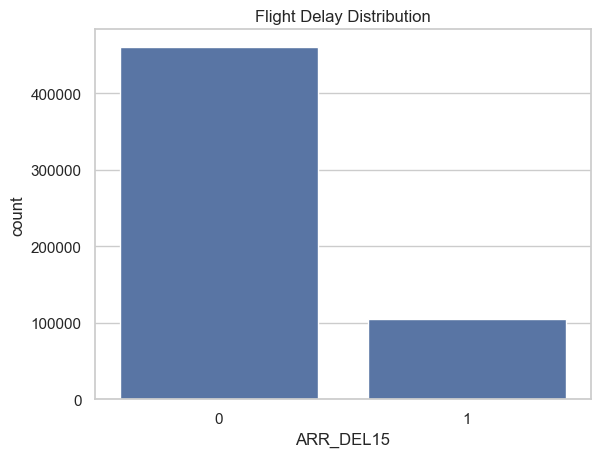

In [14]:
sns.countplot(x='ARR_DEL15', data=data)
plt.title("Flight Delay Distribution")
plt.show()

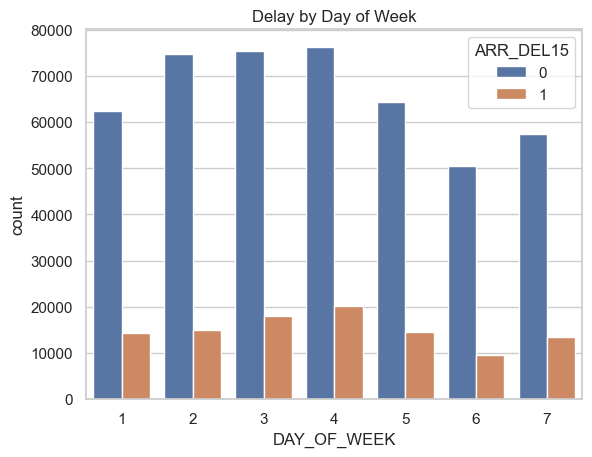

In [15]:
sns.countplot(x='DAY_OF_WEEK', hue='ARR_DEL15', data=data)
plt.title("Delay by Day of Week")
plt.show()

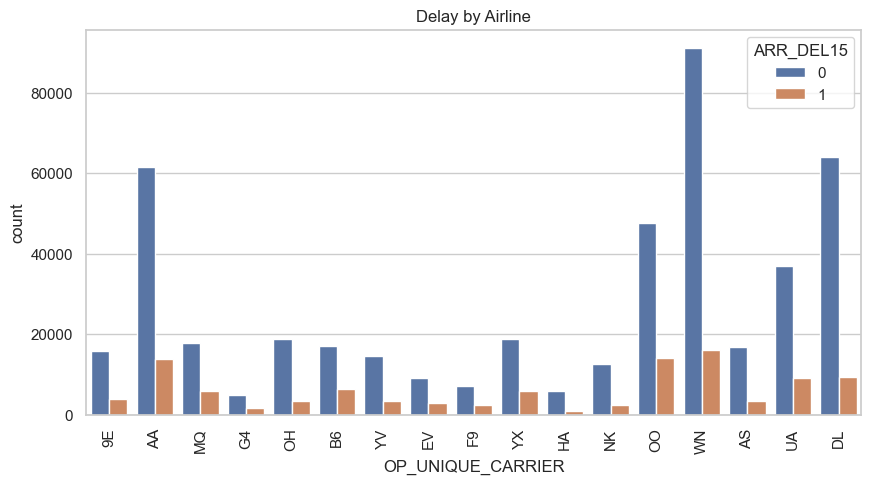

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='OP_UNIQUE_CARRIER', hue='ARR_DEL15', data=data)
plt.xticks(rotation=90)
plt.title("Delay by Airline")
plt.show()

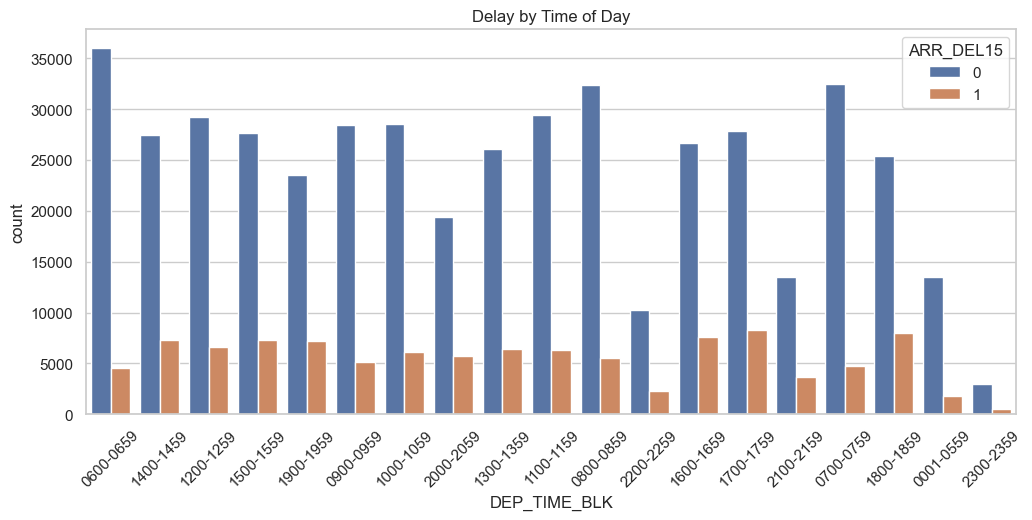

In [17]:
plt.figure(figsize=(12,5))
sns.countplot(x='DEP_TIME_BLK', hue='ARR_DEL15', data=data)
plt.xticks(rotation=45)
plt.title("Delay by Time of Day")
plt.show()

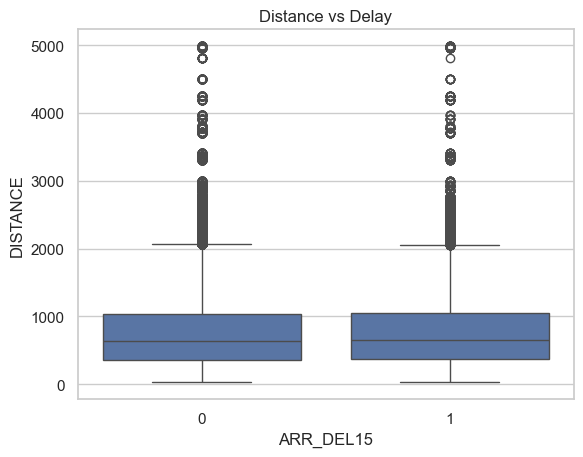

In [18]:
sns.boxplot(x='ARR_DEL15', y='DISTANCE', data=data)
plt.title("Distance vs Delay")
plt.show()

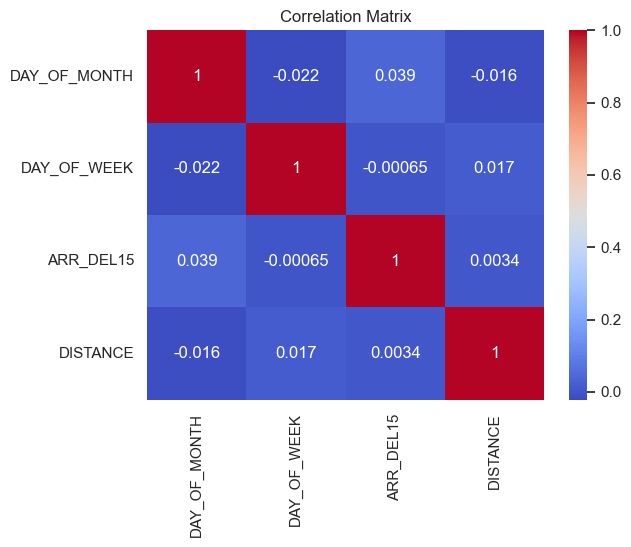

In [19]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
X = data.drop('ARR_DEL15', axis=1)
y = data['ARR_DEL15']

print(X.shape, y.shape)

(565963, 7) (565963,)


In [21]:
X = pd.get_dummies(X)

print(X.shape)

(565963, 731)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(452770, 731) (113193, 731)


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced'
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    n_jobs=-1,
    class_weight='balanced'   # 🔥 IMPORTANT
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [26]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.7522284946949016
Precision: 0.3371705831985539
Recall: 0.33433962264150946
F1 Score: 0.3357491355217659
Confusion Matrix:
 [[78059 13934]
 [14112  7088]]


In [27]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.6377867889357116
Precision: 0.27585582322043106
Recall: 0.5747169811320755
F1 Score: 0.3727817892546812
Confusion Matrix:
 [[60009 31984]
 [ 9016 12184]]


In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert sparse matrix to dense array
X_train_dense = X_train.to_numpy()
X_test_dense = X_test.to_numpy()

# Create model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train_dense, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_dense)

# Evaluation
print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Naive Bayes Results
Accuracy: 0.5665633033844849
Precision: 0.24039357459654878
Recall: 0.6084905660377359
F1 Score: 0.3446341267932997
